In [74]:
# Copyright 2019 The TensorFlow Authors All Rights Reserved.
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#     http://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.
# ==============================================================================

In [75]:
# Visualization of the YAMNet audio event classification model.
# See https://github.com/tensorflow/models/tree/master/research/audioset/yamnet/
#
# This notebook can be run in Google Colab at https://colab.research.google.com
# by either downloading this ipynb and uploading it, or by looking up the
# notebook directly on GitHub in Colab's "Open notebook" dialog.

In [76]:
# Install required packages.
# !pip install soundfile
# !pip install matplotlib
# # !git clone https://github.com/tensorflow/models.git
# # %cd models/research/audioset/yamnet

# # Download YAMNet data
# # !curl -O https://storage.googleapis.com/audioset/yamnet.h5

# # Download audio for testing
# !curl -O https://storage.googleapis.com/audioset/speech_whistling2.wav

# !ls -l

In [77]:
# Imports.
import os 

import numpy as np
import soundfile as sf

import matplotlib.pyplot as plt

import params as yamnet_params
import yamnet as yamnet_model
import tensorflow as tf
from tensorboard.plugins import projector

In [78]:
# Read in the audio.
wav_file_name = r"\\192.168.205.117\AAC_Server\NoiseTech\3-Medidas\23079-OCIO_Bilbao\CLIPS_10s\REKALDE\20231023_002931.wav"
wav_data, sr = sf.read(wav_file_name, dtype=np.int16)
waveform = wav_data / 32768.0

In [79]:
# The graph is designed for a sampling rate of 16 kHz, but higher rates should work too.
# We also generate scores at a 10 Hz frame rate.
params = yamnet_params.Params(sample_rate=sr, patch_hop_seconds=0.1)
print("Sample rate =", params.sample_rate)

Sample rate = 44100


In [80]:
# Set up the YAMNet model.
class_names = yamnet_model.class_names('yamnet_class_map.csv')
yamnet = yamnet_model.yamnet_frames_model(params)
yamnet.load_weights('yamnet.h5')

In [81]:
# Run the model.
scores, embeddings, spectrogram = yamnet(waveform)
scores = scores.numpy()
spectrogram = spectrogram.numpy()

In [84]:
# set up TensorBoard logging directory
log_dir = 'logs/yamnet_embeddings' 
if not os.path.exists(log_dir):
    os.makedirs(log_dir)# save embeddings to the logs directory

embedding_var = tf.Variable(embeddings, name='yamnet_embeddings')
checkpoint = tf.train.Checkpoint(embedding=embedding_var)
checkpoint.save(os.path.join(log_dir, 'embedding.ckpt'))

# set up the metadata (labels for the embeddings).
metadata_file = os.path.join(log_dir, 'metadata.tsv')
with open(metadata_file, 'w') as metadata_writer:
    for index in range(len(embeddings)):
        metadata_writer.write('{}\n'.format(index))

# projector config
config = projector.ProjectorConfig()
embedding_config = config.embeddings.add()
embedding_config.tensor_name = "embedding/.ATTRIBUTES/VARIABLE_VALUE"
embedding_config.metadata_path = 'metadata.tsv'

projector.visualize_embeddings(log_dir, config)

# PS C:\Users\scjaa\Documents\GitHubRepos\AAC\AI_Model\Urban_Model\test> tensorboard --logdir logs/yamnet_embeddings
# serving TensorBoard on localhost; to expose to the network, use a proxy or pass --bind_all
# TensorBoard 2.10.1 at http://localhost:6006/ (Press CTRL+C to quit)

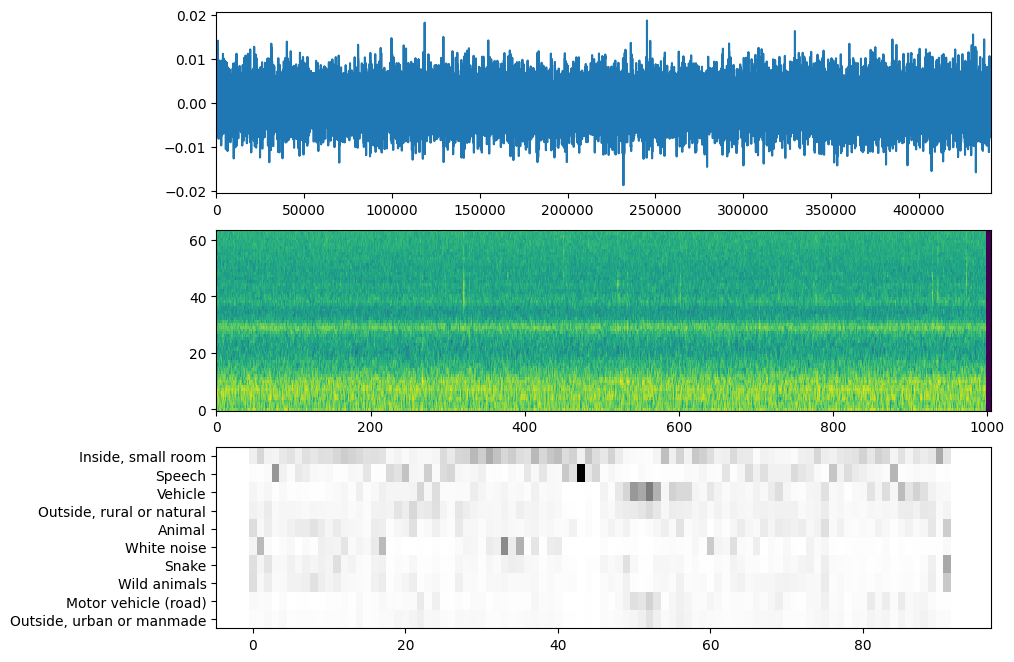

In [ ]:
# Visualize the results.
plt.figure(figsize=(10, 8))

# Plot the waveform.
plt.subplot(3, 1, 1)
plt.plot(waveform)
plt.xlim([0, len(waveform)])
# Plot the log-mel spectrogram (returned by the model).
plt.subplot(3, 1, 2)
plt.imshow(spectrogram.T, aspect='auto', interpolation='nearest', origin='lower')

# Plot and label the model output scores for the top-scoring classes.
mean_scores = np.mean(scores, axis=0)
top_N = 10
top_class_indices = np.argsort(mean_scores)[::-1][:top_N]
plt.subplot(3, 1, 3)
plt.imshow(scores[:, top_class_indices].T, aspect='auto', interpolation='nearest', cmap='gray_r')
# Compensate for the patch_window_seconds (0.96s) context window to align with spectrogram.
patch_padding = (params.patch_window_seconds / 2) / params.patch_hop_seconds
plt.xlim([-patch_padding, scores.shape[0] + patch_padding])
# Label the top_N classes.
yticks = range(0, top_N, 1)
plt.yticks(yticks, [class_names[top_class_indices[x]] for x in yticks])
_ = plt.ylim(-0.5 + np.array([top_N, 0]))
